In [ ]:
import cantera as ct
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science'])

# Definir todos los objetos "Species" según el modelo Gri30
species_dict = {S.name: S for S in ct.Species.list_from_file("gri30.yaml")}
# species_dict es un diccionario:
# {objeto1.name: objeto1, objeto2.name: objeto.2}
# keys: las propiedades "name" de los objetos species.
# values: los propios objetos species.

In [ ]:
# Crea una lista a partir de values de species (<Species H2> por ejemplo) pero añadiendo
# solo los values cuyas keys son las especies de la reacción de combustión completa.
complete_species = [species_dict[S] for S in ("CH4", "O2", "N2", "CO2", "H2O")]
# complete_species es una lista de objetos species (solo los de en combustión completa)

# Para reacción incomplete añadimos las 53 especies del GRI3.0
incomplete_species = species_dict.values()
# con la función values se crea una lista con los valores del diccionario species_dict,
# es decir, los objetos species.

gas_mix_complete = ct.Solution(thermo="ideal-gas",
                               species=complete_species,
                               transport_model='mixture-averaged',
                               kinetics='gas')
# A diferencia de Tutorial.py, aquí solo damos a la clase Solution "ideal gas"
# (el modelo termo que queremos) y la lista reducida de especies sacadas de gri30.yaml,
# en lugar de sacar todo tal cual de gri30.yaml.
gas_mix_incomplete = ct.Solution(thermo="ideal-gas",
                                 species=incomplete_species,
                                 transport_model='mixture-averaged',
                                 kinetics='gas')
# print(f"Transport model: {gas_mix_incomplete.transport_model}")
    # de gri30.yaml no he sacado transport_model, por eso no está definido

In [ ]:
#Crear vector con valores de ratio de equivalencia.
phi = np.linspace(0.6, 1.8, 100)

# Inicializar (crear con todo 0) elos vectores.
T_ad_complete = np.zeros(phi.shape)
T_ad_incomplete = np.zeros(phi.shape)
    # ERROR: poner T_ad_incomplete = T_ad_complete.

T_0 = 298 # K
p = ct.one_atm

for i in range(len(phi)):
    #print("%"*80)
    #print(f"Equivalence ratio {phi[i]}")

    # Se restablece T y p iniciales en cada bucle para calcular la T_ad
    # para cada phi cuando se parte de estas cond. iniciales.
    gas_mix_complete.TP = T_0, p
    gas_mix_incomplete.TP = T_0, p

    # El método set_equivalence_ratio de la clase Solution toma
        # · 1 valor phi,
        # · 1 str con nombres de especies y su X en el fuel (si se sabe)
        # · 1 str con nombres de especies y sus X en el oxidizer (si se saben)
    gas_mix_complete.set_equivalence_ratio(phi[i], "CH4", "O2:1, N2:3.76")
        # CH4 no lleva X porque no hay más especies en fuel (X=1).

    gas_mix_incomplete.set_equivalence_ratio(phi[i], "CH4", "O2:1, N2:3.76")

    # La función equilibrate() calcula el estado de equilibrio, a p y T ctes.,
    # que minimiza el potencial de Gibbs. Como esta combustión es espontánea,
    # ese estado final es el posterior a la combustión y como hemos impuesto H cte., su T es la T_ad.
    gas_mix_complete.equilibrate("HP")
    gas_mix_incomplete.equilibrate("HP")

    # Por tanto la T de gas_mix ahora será la Tad
    T_ad_complete[i] = gas_mix_complete.T
    T_ad_incomplete[i] = gas_mix_incomplete.T
    #print(f"T_ad_complete = {T_ad_complete[i]}")
    #print(f"T_ad_incomplete = {T_ad_incomplete[i]}")

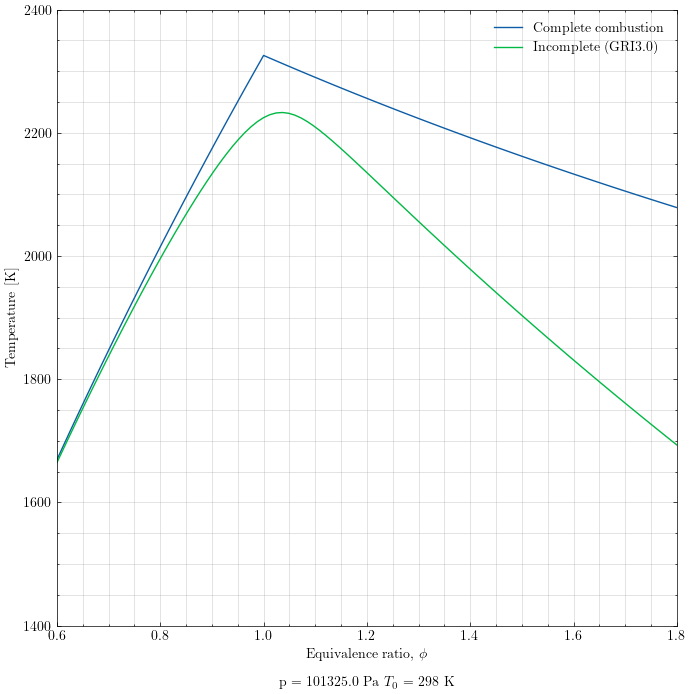

In [ ]:
plt.figure(figsize=(8,8))
# Tamaño de ventana

plt.plot(phi,
        T_ad_complete,
        label="Complete combustion",
        #lw=2
        )
plt.plot(phi,
        T_ad_incomplete,
        label="Incomplete (GRI3.0)",
        #lw=2
        )
    # phi es vector de abscisas y T_ad_incomplete, de ordenadas
    # lw: line width

ax = plt.gca()
# Ajuste Eje Y (Números cada 200, líneas cada 50)
ax.yaxis.set_major_locator(plt.MultipleLocator(200))
ax.yaxis.set_minor_locator(plt.MultipleLocator(50))
# Ajuste Eje X (Números cada 0.2, líneas cada 0.05)
ax.xaxis.set_major_locator(plt.MultipleLocator(0.2))
ax.xaxis.set_minor_locator(plt.MultipleLocator(0.05))

plt.grid(True, which='both', alpha=0.5)

plt.xlabel("Equivalence ratio, "+ r"$\phi$"+ f"\n \n p = {p} Pa    $T_{{0}}$ = {T_0} K")
plt.ylabel("Temperature [K]")

plt.legend(loc='best', fontsize=10)
    # muestra las label definidas en plt.plot

plt.xlim(0.6,1.8)
plt.ylim(1400,2400)

plt.savefig("T_ad_vs_phi.svg")
plt.show()
    # muestra el gráfico
    # plt.show() debe ir después de plt.savefig()

In [ ]:
species_dict

{'H2': <Species H2>,
 'H': <Species H>,
 'O': <Species O>,
 'O2': <Species O2>,
 'OH': <Species OH>,
 'H2O': <Species H2O>,
 'HO2': <Species HO2>,
 'H2O2': <Species H2O2>,
 'C': <Species C>,
 'CH': <Species CH>,
 'CH2': <Species CH2>,
 'CH2(S)': <Species CH2(S)>,
 'CH3': <Species CH3>,
 'CH4': <Species CH4>,
 'CO': <Species CO>,
 'CO2': <Species CO2>,
 'HCO': <Species HCO>,
 'CH2O': <Species CH2O>,
 'CH2OH': <Species CH2OH>,
 'CH3O': <Species CH3O>,
 'CH3OH': <Species CH3OH>,
 'C2H': <Species C2H>,
 'C2H2': <Species C2H2>,
 'C2H3': <Species C2H3>,
 'C2H4': <Species C2H4>,
 'C2H5': <Species C2H5>,
 'C2H6': <Species C2H6>,
 'HCCO': <Species HCCO>,
 'CH2CO': <Species CH2CO>,
 'HCCOH': <Species HCCOH>,
 'N': <Species N>,
 'NH': <Species NH>,
 'NH2': <Species NH2>,
 'NH3': <Species NH3>,
 'NNH': <Species NNH>,
 'NO': <Species NO>,
 'NO2': <Species NO2>,
 'N2O': <Species N2O>,
 'HNO': <Species HNO>,
 'CN': <Species CN>,
 'HCN': <Species HCN>,
 'H2CN': <Species H2CN>,
 'HCNN': <Species HCNN>,

In [ ]:
import cantera as ct
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science'])

# Definir todos los objetos "Species" según el modelo Gri30
species_dict = {S.name: S for S in ct.Species.list_from_file("gri30.yaml")}
# species_dict es un diccionario:
# {objeto1.name: objeto1, objeto2.name: objeto.2}
# keys: las propiedades "name" de los objetos species.
# values: los propios objetos species cuyos atributos (como los coefs para calcular cp).

In [ ]:
species_dict["H2"].input_data

{'name': 'H2',
 'composition': {'H': 2.0},
 'thermo': {'model': 'NASA7',
  'temperature-ranges': [200.0, 1000.0, 3500.0],
  'data': [[2.34433112,
    0.00798052075,
    -1.9478151e-05,
    2.01572094e-08,
    -7.37611761e-12,
    -917.935173,
    0.683010238],
   [3.3372792,
    -4.94024731e-05,
    4.99456778e-07,
    -1.79566394e-10,
    2.00255376e-14,
    -950.158922,
    -3.20502331]],
  'note': 'TPIS78'},
 'transport': {'model': 'gas',
  'geometry': 'linear',
  'diameter': 2.9200000000000004,
  'well-depth': 38.0,
  'polarizability': 0.7900000000000001,
  'rotational-relaxation': 280.0}}

In [ ]:
complete_species

[<Species CH4>, <Species O2>, <Species N2>, <Species CO2>, <Species H2O>]

In [ ]:
complete_species[0].input_data

{'name': 'CH4',
 'composition': {'C': 1.0, 'H': 4.0},
 'thermo': {'model': 'NASA7',
  'temperature-ranges': [200.0, 1000.0, 3500.0],
  'data': [[5.14987613,
    -0.0136709788,
    4.91800599e-05,
    -4.84743026e-08,
    1.66693956e-11,
    -10246.6476,
    -4.64130376],
   [0.074851495,
    0.0133909467,
    -5.73285809e-06,
    1.22292535e-09,
    -1.0181523e-13,
    -9468.34459,
    18.437318]],
  'note': 'L8/88'},
 'transport': {'model': 'gas',
  'geometry': 'nonlinear',
  'diameter': 3.7460000000000004,
  'well-depth': 141.4,
  'polarizability': 2.6,
  'rotational-relaxation': 13.0}}

In [ ]:
complete_species[0].input_data["name"]

'CH4'

In [ ]:
ct.Species.list_from_file("gri30.yaml")

[<Species H2>,
 <Species H>,
 <Species O>,
 <Species O2>,
 <Species OH>,
 <Species H2O>,
 <Species HO2>,
 <Species H2O2>,
 <Species C>,
 <Species CH>,
 <Species CH2>,
 <Species CH2(S)>,
 <Species CH3>,
 <Species CH4>,
 <Species CO>,
 <Species CO2>,
 <Species HCO>,
 <Species CH2O>,
 <Species CH2OH>,
 <Species CH3O>,
 <Species CH3OH>,
 <Species C2H>,
 <Species C2H2>,
 <Species C2H3>,
 <Species C2H4>,
 <Species C2H5>,
 <Species C2H6>,
 <Species HCCO>,
 <Species CH2CO>,
 <Species HCCOH>,
 <Species N>,
 <Species NH>,
 <Species NH2>,
 <Species NH3>,
 <Species NNH>,
 <Species NO>,
 <Species NO2>,
 <Species N2O>,
 <Species HNO>,
 <Species CN>,
 <Species HCN>,
 <Species H2CN>,
 <Species HCNN>,
 <Species HCNO>,
 <Species HOCN>,
 <Species HNCO>,
 <Species NCO>,
 <Species N2>,
 <Species AR>,
 <Species C3H7>,
 <Species C3H8>,
 <Species CH2CHO>,
 <Species CH3CHO>]

In [ ]:
help(ct.Reaction.list_from_file)

Help on method descriptor list_from_file in module cantera.reaction:

list_from_file(filename, kinetics, section='reactions')
    Create a list of Reaction objects from all of the reactions defined in a
    YAML file. Reactions from the section ``section`` will be returned.

    Directories on Cantera's input file path will be searched for the
    specified file.

